# Marketing Campaign Performance & A/B Testing Analysis

This project analyzes a marketing campaign dataset to evaluate performance, identify issues, and provide data-driven recommendations to improve conversion and retention.The analysis focuses on understanding which marketing channels perform best, how different customer segments behave, and how A/B testing can be used to optimize decision-making.

## Overview

## Business Problem

The marketing team wants to:
- Evaluate campaign performance across channels
- Understand factors influencing conversion rates
- Identify and resolve performance issues
- Use A/B testing to improve campaign effectiveness

## Contents

##  Import Libraries and Data

In [71]:
# Importing into the environment
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt

# Import marketing.csv 
marketing = pd.read_csv(r"C:\Users\User\Downloads\marketing.csv")


- Import Libraries

- Import Libraries and Data

- Data Exploration & Preprocessing

- Feature Engineering

- Exploratory Analysis & Summary Statistics

- Data Exploration

- Sentiment Analysis

- Closing Remarks and Links

## Data Exploration & Preprocessing

Examining the data

In [72]:
# Print the first five rows of the DataFrame
print(marketing.head())

      user_id date_served marketing_channel          variant converted  \
0  a100000029      1/1/18         House Ads  personalization      True   
1  a100000030      1/1/18         House Ads  personalization      True   
2  a100000031      1/1/18         House Ads  personalization      True   
3  a100000032      1/1/18         House Ads  personalization      True   
4  a100000033      1/1/18         House Ads  personalization      True   

  language_displayed language_preferred    age_group date_subscribed  \
0            English            English   0-18 years          1/1/18   
1            English            English  19-24 years          1/1/18   
2            English            English  24-30 years          1/1/18   
3            English            English  30-36 years          1/1/18   
4            English            English  36-45 years          1/1/18   

  date_canceled subscribing_channel is_retained  
0           NaN           House Ads        True  
1           NaN       

In [73]:
# Print the statistics of all columns
print(marketing.describe())

           user_id date_served marketing_channel  variant converted  \
count        10037       10021             10022    10037     10022   
unique        7309          31                 5        2         2   
top     a100000882     1/15/18         House Ads  control     False   
freq            12         789              4733     5091      8946   

       language_displayed language_preferred    age_group date_subscribed  \
count               10037              10037        10037            1856   
unique                  4                  4            7              31   
top               English            English  19-24 years         1/16/18   
freq                 9793               9275         1682             163   

       date_canceled subscribing_channel is_retained  
count            577                1856        1856  
unique           115                   5           2  
top           4/2/18           Instagram        True  
freq              15                 6

In [74]:
# Check column data types and non-missing values
print(marketing.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10037 entries, 0 to 10036
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              10037 non-null  object
 1   date_served          10021 non-null  object
 2   marketing_channel    10022 non-null  object
 3   variant              10037 non-null  object
 4   converted            10022 non-null  object
 5   language_displayed   10037 non-null  object
 6   language_preferred   10037 non-null  object
 7   age_group            10037 non-null  object
 8   date_subscribed      1856 non-null   object
 9   date_canceled        577 non-null    object
 10  subscribing_channel  1856 non-null   object
 11  is_retained          1856 non-null   object
dtypes: object(12)
memory usage: 941.1+ KB
None


Data Cleaning

In [75]:
# Change the data type the converted column
marketing['converted'] = marketing['converted'].astype('bool')

# Check the data type of is_retained, again
print(marketing['converted'].dtype)

bool


In [76]:
# Convert is_retained to a boolean
marketing['is_retained'] = marketing['is_retained'].astype(bool)

# Check the data type of is_retained, again
print(marketing['is_retained'].dtype)

bool


In [206]:
marketing['date_served'] = pd.to_datetime(marketing['date_served'])
marketing['date_subscribed'] = pd.to_datetime(marketing['date_subscribed'])
marketing['date_canceled'] = pd.to_datetime(marketing['date_canceled'])

## Feature Engineering

In [78]:
# Creating new boolean columns to identify if marketing channel was house ad or not

marketing['is_house_ads'] = np.where(marketing['marketing_channel'] == 'House Ads', True, False)

In [79]:
# Add the new column is_correct_lang is check whether the ad was shown to the user in their preferred language

marketing['is_correct_lang'] = np.where(marketing['language_preferred']==marketing['language_displayed'], 'Yes','No')

In [80]:
# Creating channel code columns to identifing marketing channel

channel_dict = {"House Ads": 1, "Instagram": 2, "Facebook": 3, "Email": 4, "Push": 5}
marketing['channel_code'] = marketing['marketing_channel'].map(channel_dict)

In [81]:
marketing['DoW'] = marketing['date_subscribed'].dt.dayofweek
print(marketing['DoW'])

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
10032    2.0
10033    2.0
10034    2.0
10035    2.0
10036    2.0
Name: DoW, Length: 10037, dtype: float64


## Exploratory Analysis & Summary Statistics

Marketing Performance Metrics

In [82]:
# Group by date_served and count number of unique user_id's
daily_users = marketing.groupby('date_served')['user_id'].nunique()

# Print head of daily_users
print(daily_users.head())

date_served
2018-01-01    362
2018-01-02    374
2018-01-03    348
2018-01-04    323
2018-01-05    319
Name: user_id, dtype: int64


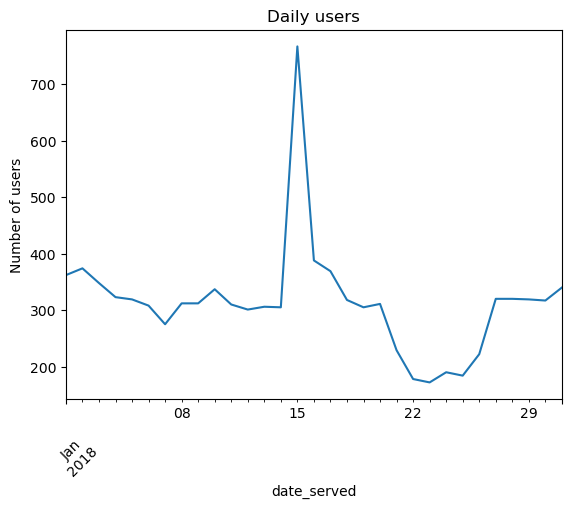

In [83]:
# visualize daily_users
daily_users.plot()
plt.title('Daily users')
plt.ylabel('Number of users')
plt.xticks(rotation =45 )
plt.show()

In [84]:
# Calculate the conversion rate

# Calculate the number of people we marketed to
total_converted = marketing['user_id'].nunique()

# Calculate the number of people who subscribed
subscribers = marketing[marketing['converted']== True]['user_id'].nunique()

# Calculate the conversion rate
conversion_rate = subscribers/total_converted
print(round(conversion_rate*100, 2), "%")

14.09 %


In [115]:
# Calculate the retention rate

# Calculate the number of subscribers
total_subscribers = marketing[marketing['converted']==True]['user_id'].nunique()

# Calculate the number of people who remained subscribed

retained = subscribers[subscribers['is_retained'] == True]['user_id'].nunique()

# Calculate the retention rate
retention_rate = retained/total_subscribers
print(total_subscribers)
print(retained)
print(round(retention_rate*100, 2), "%")

1030
696
67.57 %


Customer Segmentation

In [116]:
# Group by subscribing_channel and counting unique retented users
retained = marketing[marketing['is_retained'] == True]\
                          .groupby(['subscribing_channel'])\
                            ['user_id'].nunique()
print(retained)  

subscribing_channel
Email        141
Facebook     152
House Ads    173
Instagram    158
Push          54
Name: user_id, dtype: int64


In [117]:
# Group by subscribing_channel and counting unique converted users
subscribers = marketing[marketing['converted'] == True]\
                          .groupby(['subscribing_channel'])\
                            ['user_id'].nunique()
print(subscribers)

subscribing_channel
Email        161
Facebook     221
House Ads    298
Instagram    232
Push          77
Name: user_id, dtype: int64


In [118]:
# Calculate the retention rate across subscribing channel

channel_retention_rate = (retained/subscribers)*100
print(channel_retention_rate)

subscribing_channel
Email        87.577640
Facebook     68.778281
House Ads    58.053691
Instagram    68.103448
Push         70.129870
Name: user_id, dtype: float64


In [119]:
# Comparing language conversion rate

# Group by language_displayed and count unique users
total = marketing.groupby('language_displayed')['user_id'].nunique()

# Group by language_displayed and count unique conversions
subscribers = marketing[marketing['converted']==True].groupby('language_displayed')\
                        ['user_id'].nunique()

# Calculate the conversion rate for all languages
language_conversion_rate = round(subscribers/total,3)
print(language_conversion_rate)

language_displayed
Arabic     0.500
English    0.131
German     0.716
Spanish    0.200
Name: user_id, dtype: float64


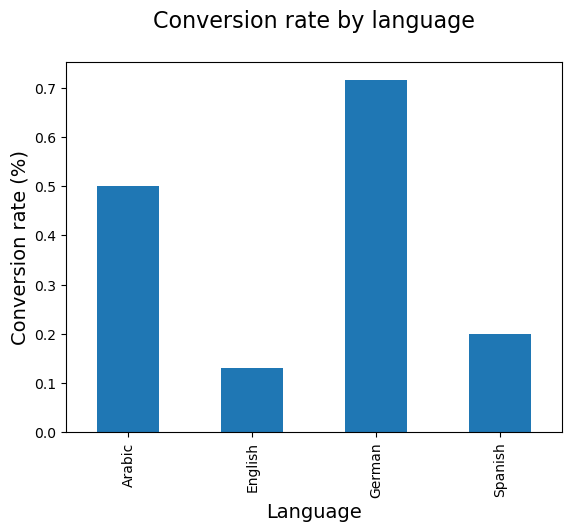

In [120]:
# Create a bar chart using language_conversion_rate DataFrame
language_conversion_rate.plot(kind ='bar')

# Add a title and x and y-axis labels
plt.title('Conversion rate by language\n', size = 16)
plt.xlabel('Language', size = 14
)
plt.ylabel('Conversion rate (%)', size = 14)

# Display the plot
plt.show()

In [121]:
# Calculate the conversion rate per day

# Group by date_served and count unique users
total = marketing.groupby('date_served')['user_id'].nunique()

# Group by date_served and count unique converted users
subscribers = marketing[marketing['converted']==True].groupby('date_served')['user_id'].nunique()

daily_conversion_rate = subscribers/total
print(daily_conversion_rate.head())

date_served
2018-01-01    0.099448
2018-01-02    0.098930
2018-01-03    0.103448
2018-01-04    0.108359
2018-01-05    0.125392
Name: user_id, dtype: float64


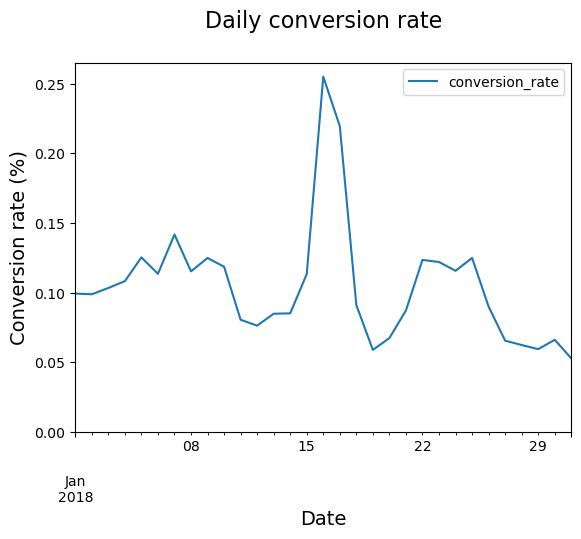

In [122]:
#Visualize daily conversion rate

# Reset index to turn the results into a DataFrame
daily_conversion_rate = pd.DataFrame(daily_conversion_rate.reset_index())

# Rename columns
daily_conversion_rate.columns = ['date_served', 'conversion_rate']

# Create a line chart using daily_conversion_rate
daily_conversion_rate.plot('date_served', 'conversion_rate')

plt.title('Daily conversion rate\n', size = 16)
plt.ylabel('Conversion rate (%)', size = 14)
plt.xlabel('Date', size = 14)

# Set the y-axis to begin at 0
plt.ylim(0)

# Display the plot
plt.show()

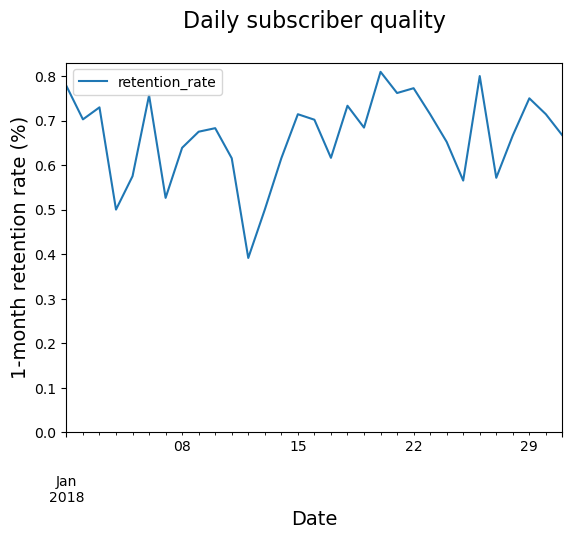

In [123]:
#Calculating subscriber quality

# Group by date_subscribed and count unique users
subscribed = marketing.groupby(['date_subscribed'])['user_id'].nunique()
# Group by date_subscribed and count

retained = marketing[marketing['is_retained'] == True].groupby(['date_subscribed'])['user_id'].nunique()
                    
# Calculate subscriber quality across dates
daily_retention_rate = retained/subscribed

# Reset index to turn the Series into a DataFrame
daily_retention_rate = pd.DataFrame(daily_retention_rate.reset_index())
# Rename columns
daily_retention_rate.columns = ['date_subscribed', 'retention_rate']

# Create a line chart using the daily_retention DataFrame
daily_retention_rate.plot('date_subscribed', 'retention_rate')

plt.title('Daily subscriber quality\n', size = 16)
plt.ylabel('1-month retention rate (%)', size = 14)
plt.xlabel('Date', size = 14)
# Set the y-axis to begin at 0
plt.ylim(0)
plt.show()



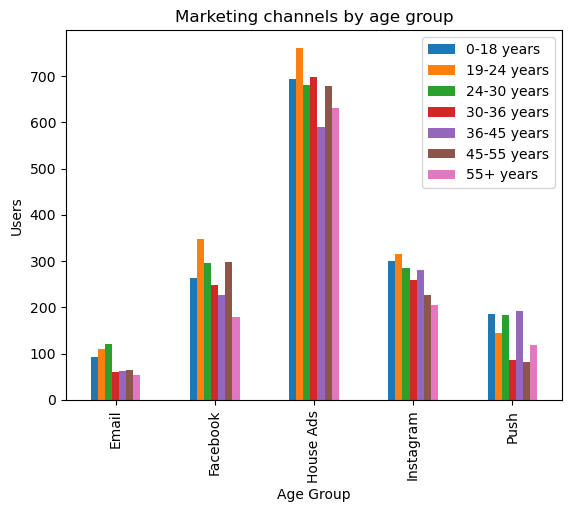

In [124]:
# Marketing channels across age groups

channel_age = marketing.groupby(['marketing_channel', 'age_group'])\
                                ['user_id'].count()

# Unstack channel_age and transform it into a DataFrame
channel_age_df = pd.DataFrame (channel_age.unstack(level = 1))
 
# Plot channel_age
channel_age_df.plot(kind = 'bar')
plt.title('Marketing channels by age group')
plt.xlabel('Age Group')
plt.ylabel('Users')
plt.legend(loc = 'upper right', 
           labels = channel_age_df.columns.values)
plt.show()

In [125]:
# preferred language over time

language = marketing.groupby(['date_served', 'language_preferred'])['user_id'].count()
print(language.head())

date_served  language_preferred
2018-01-01   Arabic                  4
             English               355
             German                  5
             Spanish                11
2018-01-02   Arabic                  4
Name: user_id, dtype: int64


In [126]:
# Unstacking 
language = pd.DataFrame(language.unstack(level=1))
print(language.head())

language_preferred  Arabic  English  German  Spanish
date_served                                         
2018-01-01             4.0    355.0     5.0     11.0
2018-01-02             4.0    397.0     6.0     10.0
2018-01-03             3.0    374.0     3.0      8.0
2018-01-04             2.0    318.0     2.0     14.0
2018-01-05             1.0    314.0     2.0     14.0


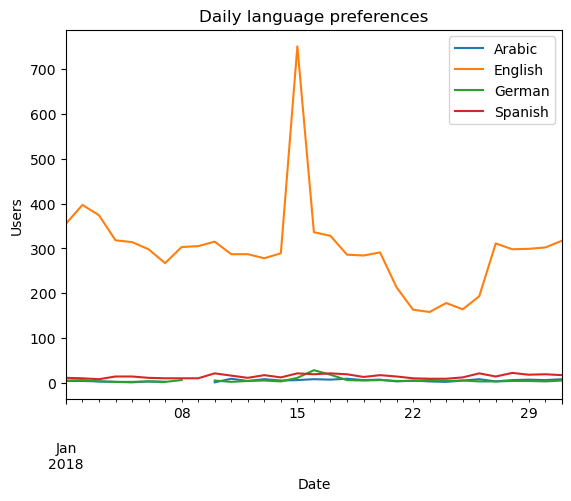

In [127]:
# Plotting preferred language over time
language.plot()
plt.title('Daily language preferences')
plt.xlabel('Date')
plt.ylabel('Users')
plt.legend(loc = 'upper right',labels = language.columns.values)
plt.show()


In [128]:
# preferred language across age groups

# Create DataFrame grouped by age and language preference
language_age = marketing.groupby(['language_preferred','age_group'])['user_id'].count()
language_age = pd.DataFrame(language_age.unstack(level=1))
print(language_age.head())


age_group           0-18 years  19-24 years  24-30 years  30-36 years  \
language_preferred                                                      
Arabic                      19           26           19           19   
English                   1421         1560         1442         1251   
German                      31           29           35           16   
Spanish                     68           67           72           69   

age_group           36-45 years  45-55 years  55+ years  
language_preferred                                       
Arabic                       19           21         22  
English                    1260         1240       1101  
German                       19           25         12  
Spanish                      55           67         52  


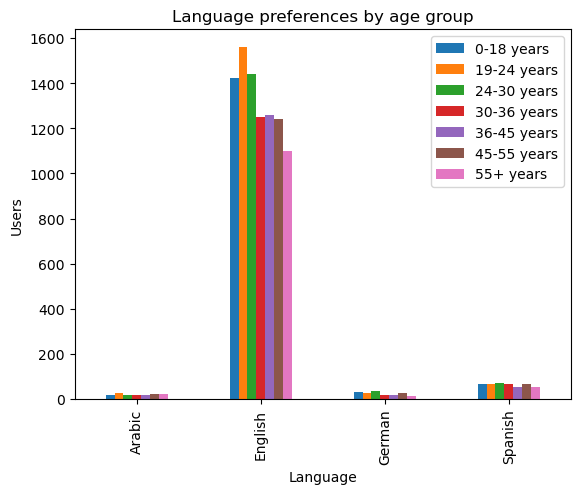

In [129]:
# Plotting language preferences by age group
language_age.plot(kind='bar')
plt.title('Language preferences by age group')
plt.xlabel('Language')
plt.ylabel('Users')
plt.legend(loc = 'upper right', labels = language_age.columns)
plt.show()

In [130]:
# # Count the subs by subscribing channel and day
retention_total = marketing.groupby(['date_subscribed',
                                     'subscribing_channel'])['user_id'].nunique()

# Print results
print(retention_total.head())

date_subscribed  subscribing_channel
2018-01-01       Email                   1
                 Facebook                8
                 House Ads              16
                 Instagram               8
                 Push                    3
Name: user_id, dtype: int64


In [131]:
# Sum the retained subs by subscribing channel and date subscribed
retention_subs = marketing[marketing['is_retained']==True].groupby(['date_subscribed','subscribing_channel'])['user_id'].nunique()

# Print results
print(retention_subs.head())

date_subscribed  subscribing_channel
2018-01-01       Email                   1
                 Facebook                7
                 House Ads              11
                 Instagram               6
                 Push                    3
Name: user_id, dtype: int64


## Buillding Functions to Automate Analysis

In [132]:
def conversion_rate(dataframe, column_names):
    # Total number of converted users
    column_conv = dataframe[dataframe['converted']==True].groupby(column_names)['user_id'].nunique()

    # Total number users
    column_total = dataframe.groupby(column_names)['user_id'].nunique()  

    # Conversion rate 
    conversion_rate = column_conv/column_total
    # Fill missing values with 0
    conversion_rate = conversion_rate.fillna(0)
    return conversion_rate

In [133]:
def plotting_conv(dataframe):
    for column in dataframe:
        # Plot column by dataframe's index
        plt.plot(dataframe.index, dataframe[column])
        plt.title('Daily ' + str(column) + ' conversion rate\n', 
                  size = 16)
        plt.ylabel('Conversion rate', size = 14)
        plt.xlabel('Date', size = 14)
        # Show plot
        plt.show()  
        plt.clf()
        

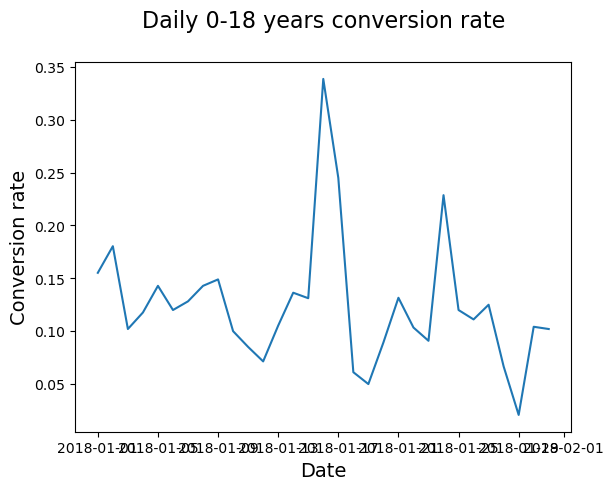

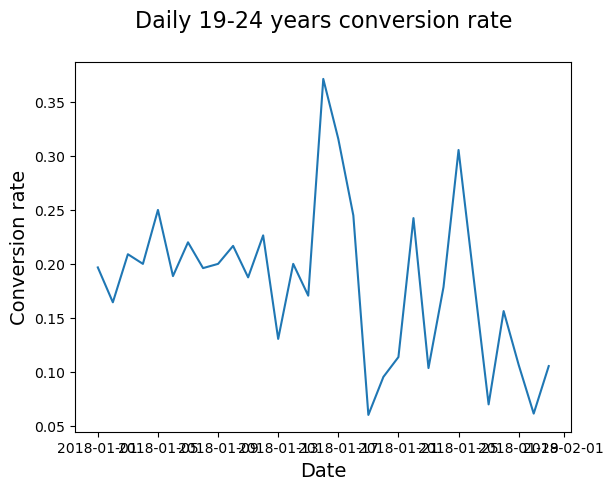

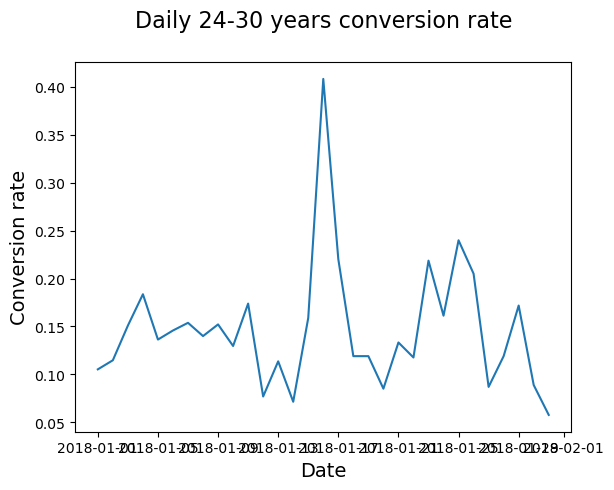

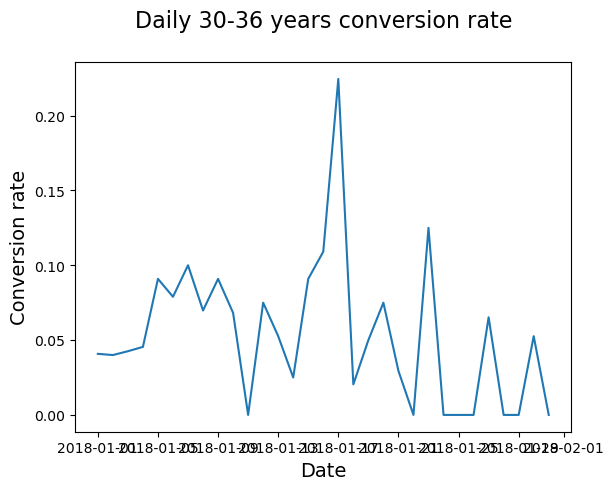

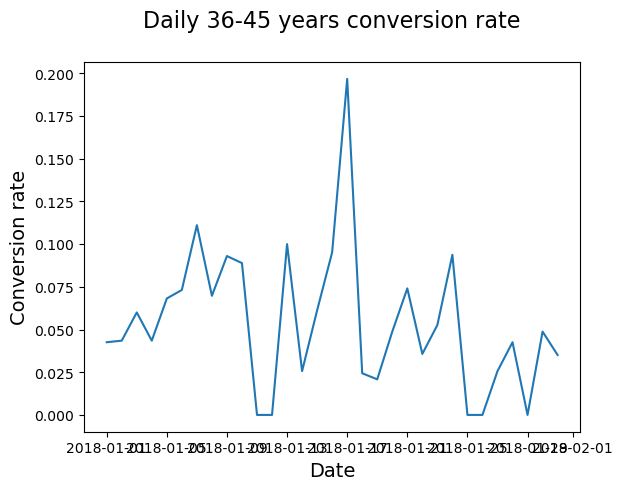

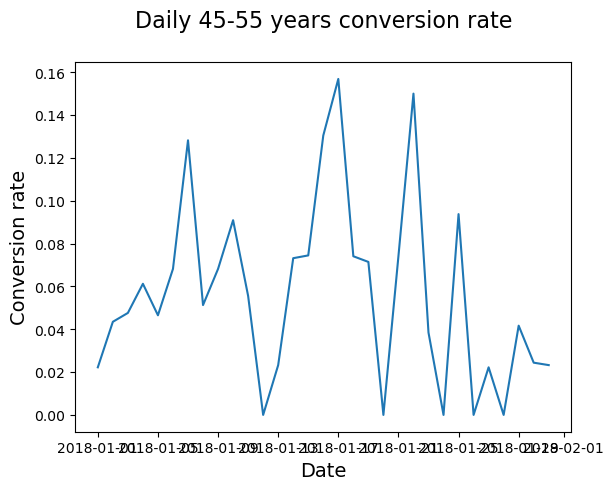

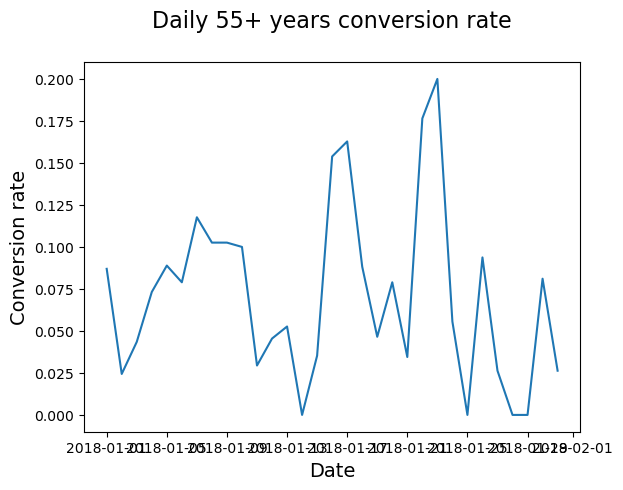

<Figure size 640x480 with 0 Axes>

In [134]:
# Calculate conversion rate by date served and age group
age_group_conv = conversion_rate(marketing,['date_served','age_group'])

# Unstack age_group_conv and create a DataFrame
age_group_df = pd.DataFrame(age_group_conv.unstack(level=1))

# Plot the results using automated function
plotting_conv(age_group_df)

date_served  age_group  
2018-01-01   0-18 years     0.155172
             19-24 years    0.196721
             24-30 years    0.105263
             30-36 years    0.040816
             36-45 years    0.042553
                              ...   
2018-01-31   24-30 years    0.057692
             30-36 years    0.000000
             36-45 years    0.035088
             45-55 years    0.023256
             55+ years      0.026316
Name: user_id, Length: 217, dtype: float64


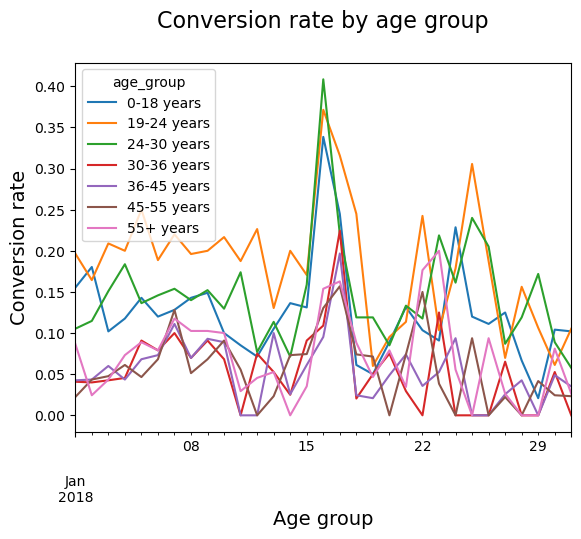

In [135]:
# Calculate conversion rate by age_group using the auntomated funtion

age_group_conv = conversion_rate(marketing, ['date_served', 'age_group'])
print(age_group_conv)

# Unstack and create a DataFrame
age_group_df = pd.DataFrame(age_group_conv.unstack(level=1))

# Visualize conversion by age_group
age_group_df.plot()
plt.title('Conversion rate by age group\n', size = 16)
plt.ylabel('Conversion rate', size = 14)
plt.xlabel('Age group', size = 14)
plt.show()

## Conversion Drop Investigation

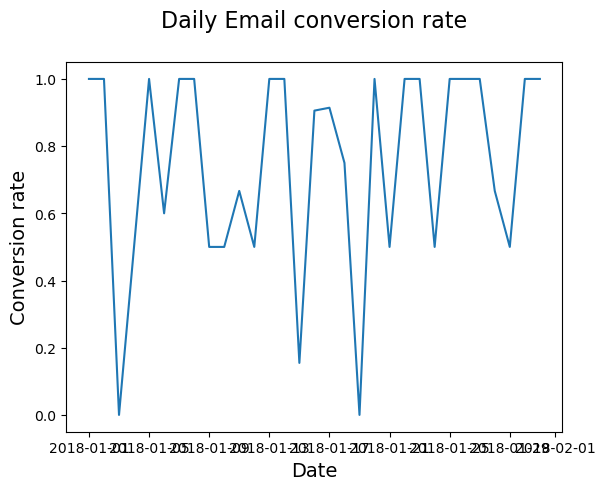

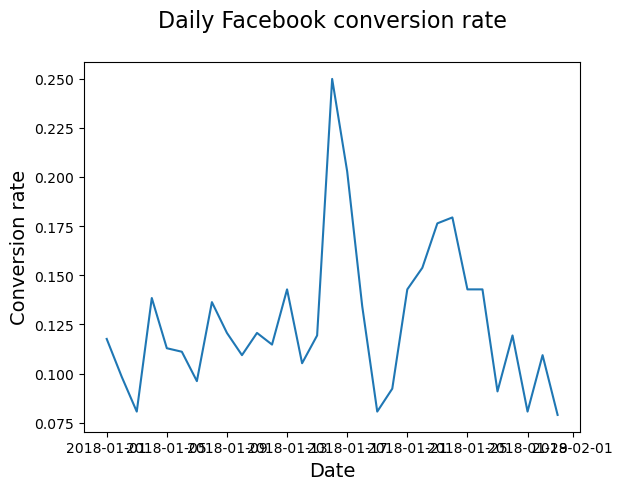

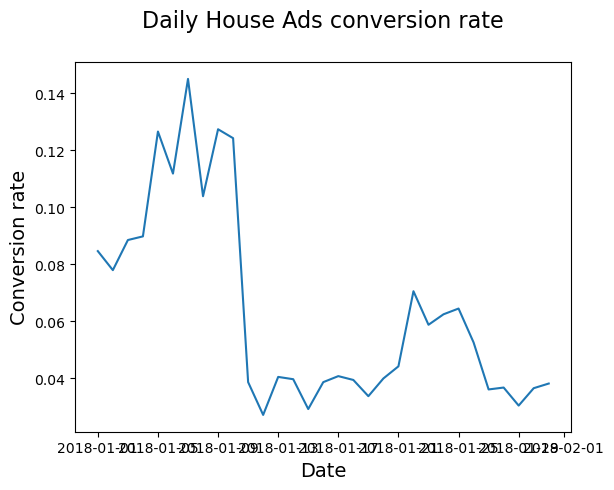

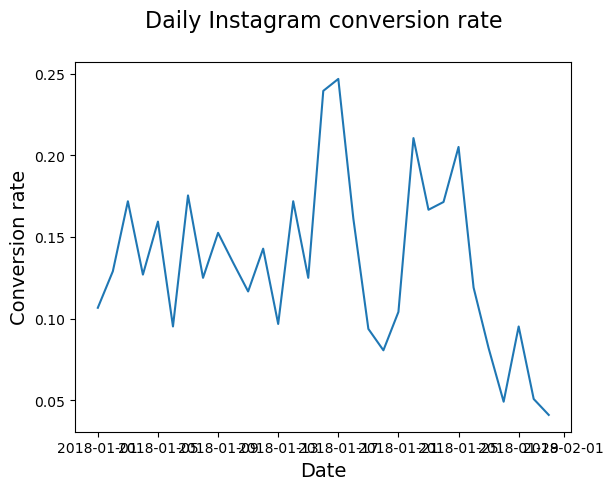

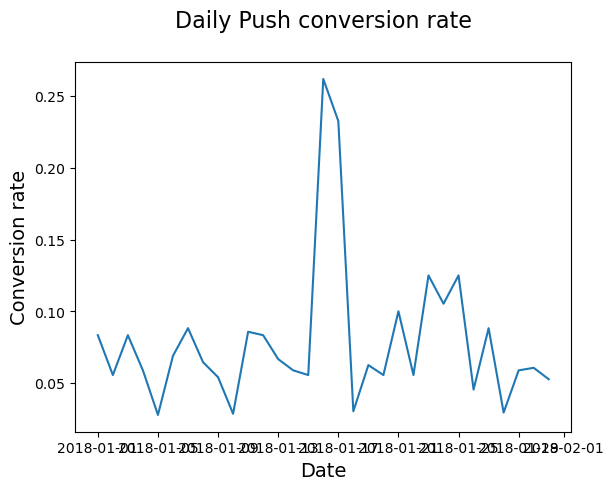

<Figure size 640x480 with 0 Axes>

In [136]:
# Calculate conversion rate by date served and channel
daily_conv_channel = conversion_rate(marketing,['date_served','marketing_channel'])

# Unstack daily_conv_channel and convert it to a DataFrame
daily_conv_channel = pd.DataFrame(daily_conv_channel.unstack(level = 1))

# Plot results of daily_conv_channel
plotting_conv(daily_conv_channel)


## A sudden decrease in conversion rate on January 11.

Analyzing House ads conversion rate

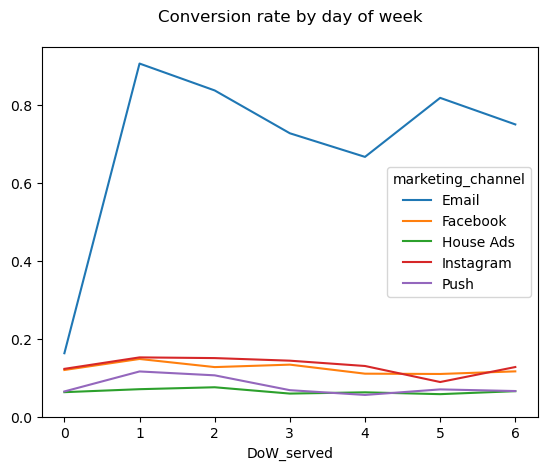

In [138]:
# Add day of week column to marketing
marketing['DoW_served'] = marketing['date_served'].dt.dayofweek

# Calculate conversion rate by day of week
DoW_conversion = conversion_rate(marketing, ['DoW_served', 'marketing_channel'])


#  Unstack channels
DoW_df = pd.DataFrame(DoW_conversion.unstack(level=1))

# Plot conversion rate by day of week
DoW_df.plot()
plt.title('Conversion rate by day of week\n')
plt.ylim(0)
plt.show()

## As you can see, email is particularly high and may be reflective of a tracking error,
## but house ads appear stable across the week with a slight peak on Tuesday

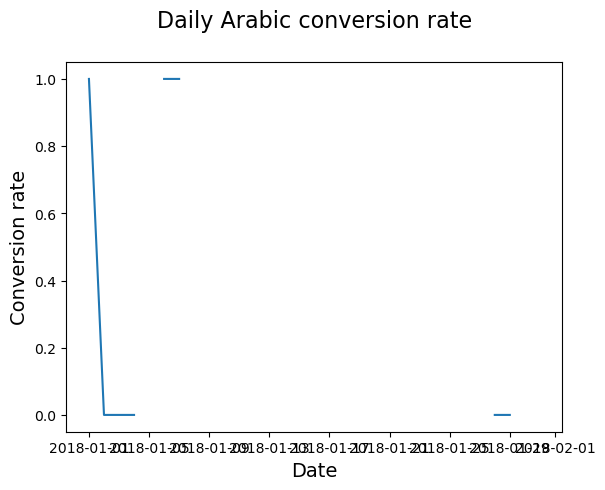

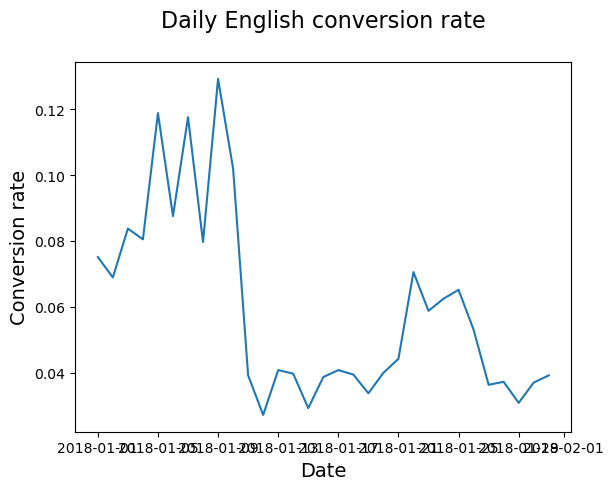

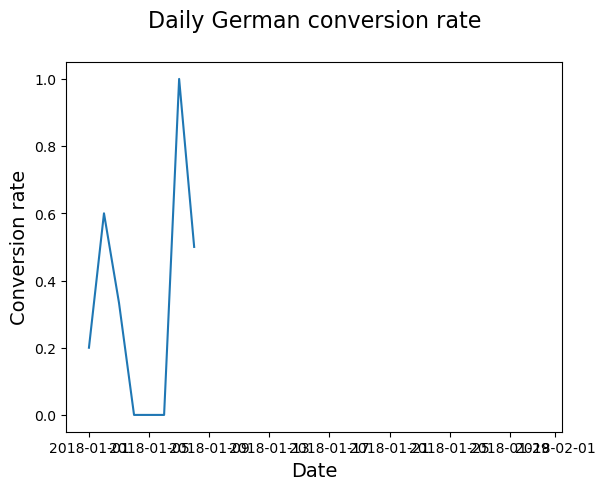

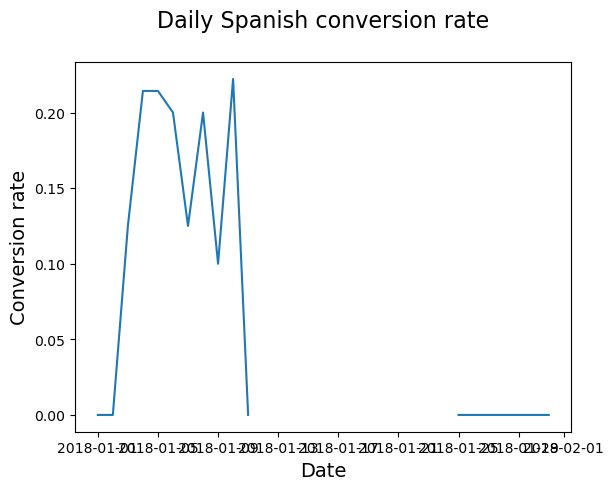

<Figure size 640x480 with 0 Axes>

In [139]:
# House ads conversion by language
# Isolate the rows where marketing channel is House Ads
house_ads = marketing[marketing['marketing_channel']=='House Ads']

# Calculate conversion by date served, and language displayed
conv_lang_channel = conversion_rate(house_ads,['date_served','language_displayed'])

# Unstack conv_lang_channel
conv_lang_df = pd.DataFrame(conv_lang_channel.unstack(level=1))

# Use your plotting function to display results
plotting_conv(conv_lang_df)

# English conversion rate drops around the 11th, and there do not appear to be ads served in other languages for a two week period.

In [141]:
# Add the new column is_correct_lang
house_ads['is_correct_lang'] = np.where(
    house_ads['language_displayed'] == house_ads['language_preferred'], 
    'Yes', 
    'No')

# Groupby date_served and correct_language
language_check = house_ads.groupby(['date_served', 'is_correct_lang'])['is_correct_lang'].count()
# Unstack language_check and fill missing values with 0's
language_check_df = pd.DataFrame(language_check.unstack(level=1)).fillna(0)

# Print results
print(language_check_df)

is_correct_lang    No    Yes
date_served                 
2018-01-01        2.0  189.0
2018-01-02        3.0  247.0
2018-01-03        0.0  220.0
2018-01-04        0.0  168.0
2018-01-05        0.0  160.0
2018-01-06        1.0  151.0
2018-01-07        2.0  130.0
2018-01-08        0.0  154.0
2018-01-09        0.0  157.0
2018-01-10        0.0  170.0
2018-01-11       20.0  135.0
2018-01-12       18.0  130.0
2018-01-13       26.0  122.0
2018-01-14       20.0  131.0
2018-01-15       16.0  192.0
2018-01-16       28.0  127.0
2018-01-17       21.0  127.0
2018-01-18       31.0  121.0
2018-01-19       22.0  127.0
2018-01-20       28.0  124.0
2018-01-21       14.0  100.0
2018-01-22       13.0   72.0
2018-01-23       16.0   69.0
2018-01-24       13.0   83.0
2018-01-25       19.0   74.0
2018-01-26       24.0   92.0
2018-01-27       18.0  149.0
2018-01-28       28.0  136.0
2018-01-29       24.0  142.0
2018-01-30       23.0  145.0
2018-01-31       23.0  135.0


C:\Users\User\AppData\Local\Temp\ipykernel_27112\2641422307.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house_ads['is_correct_lang'] = np.where(


is_correct_lang    No    Yes       pct
date_served                           
2018-01-01        2.0  189.0  0.989529
2018-01-02        3.0  247.0  0.988000
2018-01-03        0.0  220.0  1.000000
2018-01-04        0.0  168.0  1.000000
2018-01-05        0.0  160.0  1.000000
2018-01-06        1.0  151.0  0.993421
2018-01-07        2.0  130.0  0.984848
2018-01-08        0.0  154.0  1.000000
2018-01-09        0.0  157.0  1.000000
2018-01-10        0.0  170.0  1.000000
2018-01-11       20.0  135.0  0.870968
2018-01-12       18.0  130.0  0.878378
2018-01-13       26.0  122.0  0.824324
2018-01-14       20.0  131.0  0.867550
2018-01-15       16.0  192.0  0.923077
2018-01-16       28.0  127.0  0.819355
2018-01-17       21.0  127.0  0.858108
2018-01-18       31.0  121.0  0.796053
2018-01-19       22.0  127.0  0.852349
2018-01-20       28.0  124.0  0.815789
2018-01-21       14.0  100.0  0.877193
2018-01-22       13.0   72.0  0.847059
2018-01-23       16.0   69.0  0.811765
2018-01-24       13.0   8

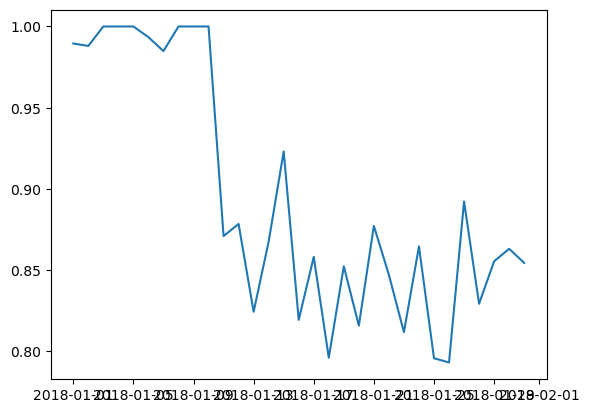

In [142]:
# Divide the count where language is correct by the row sum
language_check_df['pct'] = language_check_df['Yes']/language_check_df.sum(axis=1)
print(language_check_df)
# Plot and show your results
plt.plot(language_check_df.index.values, language_check_df['pct'])
plt.show()

## 4. A/B Testing Analysis
### Estimating what conversion might have look

In [144]:
house_ads = marketing[marketing['marketing_channel']=='House Ads']
# Calculate pre-error conversion rate
house_ads_bug = house_ads[house_ads['date_served'] < '2018-01-11']
lang_conv = conversion_rate(house_ads_bug, ['language_displayed']) 

# Index other language conversion rate against English
spanish_index = lang_conv['Spanish']/lang_conv['English']
arabic_index = lang_conv['Arabic']/lang_conv['English']
german_index = lang_conv['German']/lang_conv['English']

print("Spanish index:", spanish_index)
print("Arabic index:", arabic_index)
print("German index:", german_index)

Spanish index: 1.681924882629108
Arabic index: 5.045774647887324
German index: 4.485133020344287


In [161]:
# Group house_ads by date and language
converted = house_ads.groupby(['date_served','language_preferred']) .agg({'user_id':'nunique','converted':'sum'})

# Unstack converted
converted_df = pd.DataFrame(converted.unstack(level=1))
print(converted)

                                user_id  converted
date_served language_preferred                    
2018-01-01  Arabic                    2          2
            English                 171         13
            German                    5          1
            Spanish                  11          0
2018-01-02  Arabic                    3          0
...                                 ...        ...
2018-01-30  Spanish                  18          2
2018-01-31  Arabic                    7          1
            English                 130          4
            German                    4          0
            Spanish                  16          1

[119 rows x 2 columns]


In [181]:
# Create English conversion rate column for affected period
converted['english_conv_rate'] = converted.loc['2018-01-11':'2018-01-31'][('converted','English')]/converted.loc['2018-01-11':'2018-01-31'][('user_id','English')]

# Create expected conversion rates for each language
converted['expected_spanish_rate'] = converted['english_conv_rate']*spanish_index
converted['expected_arabic_rate'] = converted['english_conv_rate']*arabic_index
converted['expected_german_rate'] = converted['english_conv_rate']*german_index

# Multiply number of users by the expected conversion rate
# Multiply number of users by the expected conversion rate
converted['expected_spanish_conv'] = converted['expected_spanish_rate'] * converted[('user_id','Spanish')]
converted['expected_arabic_conv'] = converted['expected_arabic_rate'] * converted[('user_id','Arabic')]
converted['expected_german_conv'] = converted['expected_german_rate'] * converted[('user_id','German')]


print(converted['expected_spanish_conv'].sum())
print(converted['expected_arabic_conv'].sum())
print(converted['expected_german_conv'].sum())

18.041698221595702
18.145765603638086
14.2700286485868


In [182]:
# Use .loc to slice only the relevant dates
converted = converted.loc['2018-01-11':'2018-01-31']

# Sum expected subscribers for each language
expected_subs = converted['expected_spanish_conv'].sum() + converted['expected_arabic_conv'].sum() + converted['expected_german_conv'].sum()

# Calculate how many subscribers we actually got
actual_subs = converted[('converted','Spanish')].sum() + converted[('converted','Arabic')].sum() + converted[('converted','German')].sum()

# Subtract how many subscribers we got despite the bug
lost_subs = expected_subs - actual_subs
print(lost_subs)
print(expected_subs)
print(actual_subs)


24.457492473820594
50.457492473820594
26.0


## 4. A/B Testing Analysis

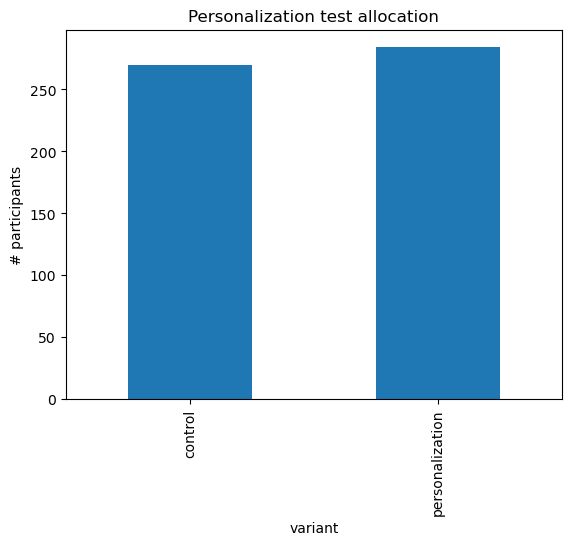

In [183]:
# Test allocation
# Subset the DataFrame
email = marketing[marketing['marketing_channel']=='Email']
# Group the email DataFrame by variant 
alloc = email.groupby('variant')['user_id'].nunique()

# Plot a bar chart of the test allocation
alloc.plot(kind='bar')
plt.title('Personalization test allocation')
plt.ylabel('# participants')
plt.show()

In [184]:
# Comparing conversion rates

# Group marketing by user_id and variant
subscribers = email.groupby(['user_id', 
                             'variant'])['converted'].max()
subscribers_df = pd.DataFrame(subscribers.unstack(level=1)) 

# Drop missing values from the control column
control = subscribers_df['control'].dropna()

# Drop missing values from the personalization column
personalization = subscribers_df['personalization'].dropna()

print('Control conversion rate:', np.mean(control))
print('Personalization conversion rate:', np.mean(personalization))

Control conversion rate: 0.2814814814814815
Personalization conversion rate: 0.3908450704225352


In [190]:
# Creating a lift function

def lift(a,b):
    # Calcuate the mean of a and b
    a_mean = np.mean(a)
    b_mean = np.mean(b)
    
    # Calculate the lift using a_mean and b_mean
    lift = (b_mean - a_mean)/a_mean
  
    return str(round(lift*100, 2)) + '%'
  
# Print lift() with control and personalization as inputs
print(lift(control, personalization))


38.85%


In [201]:
# Evaluating statistical significance
import scipy.stats as stats
from scipy.stats import ttest_ind

t = ttest_ind(control.astype(float), personalization.astype(float))
print(t)

TtestResult(statistic=np.float64(-2.734329944750507), pvalue=np.float64(0.0064514878446941815), df=np.float64(552.0))


# A/B testing for segmentation

In [202]:
# Building an A/B test segmenting function

def ab_segmentation(segment):
  # Build a for loop for each segment in marketing
  for subsegment in np.unique(marketing[segment].values):
      print(subsegment)
      
      # Limit marketing to email and subsegment      
      email = marketing[(marketing['marketing_channel'] == 'Email') & (marketing[segment] == subsegment)]

      subscribers = email.groupby(['user_id', 'variant'])['converted'].max()
      subscribers = pd.DataFrame(subscribers.unstack(level=1)) 
      control = subscribers['control'].dropna().astype(float)
      personalization = subscribers['personalization'].dropna().astype(float)

      print('lift:', lift(control, personalization))
      print('t-statistic:', stats.ttest_ind(control, personalization), '\n\n')

In [204]:
# Use ab_segmentation on language displayed
ab_segmentation('language_displayed')

Arabic
lift: 50.0%
t-statistic: TtestResult(statistic=np.float64(-0.5773502691896255), pvalue=np.float64(0.5795840000000001), df=np.float64(8.0)) 


English
lift: 39.0%
t-statistic: TtestResult(statistic=np.float64(-2.2183598646203215), pvalue=np.float64(0.026991701290720503), df=np.float64(486.0)) 


German
lift: -1.62%
t-statistic: TtestResult(statistic=np.float64(0.19100834180787182), pvalue=np.float64(0.8494394170062678), df=np.float64(42.0)) 


Spanish
lift: 166.67%
t-statistic: TtestResult(statistic=np.float64(-2.3570226039551585), pvalue=np.float64(0.040156718110477524), df=np.float64(10.0)) 




C:\Users\User\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [205]:
# Use ab_segmentation on age group
ab_segmentation('age_group')

0-18 years
lift: 121.4%
t-statistic: TtestResult(statistic=np.float64(-2.966044912142212), pvalue=np.float64(0.003872449439129706), df=np.float64(89.0)) 


19-24 years
lift: 106.24%
t-statistic: TtestResult(statistic=np.float64(-3.0317943847866697), pvalue=np.float64(0.0030623836114689195), df=np.float64(105.0)) 


24-30 years
lift: 161.19%
t-statistic: TtestResult(statistic=np.float64(-3.861539544326876), pvalue=np.float64(0.00018743381094867337), df=np.float64(114.0)) 


30-36 years
lift: -100.0%
t-statistic: TtestResult(statistic=np.float64(3.185906464414798), pvalue=np.float64(0.0023238487431765337), df=np.float64(58.0)) 


36-45 years
lift: -85.23%
t-statistic: TtestResult(statistic=np.float64(2.431790127931851), pvalue=np.float64(0.01797568600978825), df=np.float64(61.0)) 


45-55 years
lift: -72.22%
t-statistic: TtestResult(statistic=np.float64(2.0654991273179326), pvalue=np.float64(0.04306233968820123), df=np.float64(62.0)) 


55+ years
lift: -100.0%
t-statistic: TtestResult(st